### Imports + paths

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path

from sklearn.metrics import mean_absolute_error, mean_squared_error
from hyperopt import fmin, tpe, hp, Trials, STATUS_OK

import mlflow

from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
import joblib

D:\data analytics\TimeSeries\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
ROOT = Path.cwd().parents[0]  # week_03 -> project root
DATA_PATH = ROOT / "Data" / "cleaned_timeseries.csv"
MODELS_DIR = ROOT / "models"
MODELS_DIR.mkdir(exist_ok=True)

print("DATA:", DATA_PATH)
print("MODELS:", MODELS_DIR)

DATA: D:\data analytics\TimeSeries\Data\cleaned_timeseries.csv
MODELS: D:\data analytics\TimeSeries\models


### load + feature engineering

In [3]:
df = pd.read_csv(DATA_PATH)
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").set_index("date")

# Lags + rolling (PAST-ONLY)
df["lag_1"]  = df["unit_sales"].shift(1)
df["lag_7"]  = df["unit_sales"].shift(7)
df["lag_14"] = df["unit_sales"].shift(14)
df["rolling_mean_7"] = df["unit_sales"].shift(1).rolling(7).mean()
df["rolling_std_7"]  = df["unit_sales"].shift(1).rolling(7).std()

# Calendar
df["day_of_week"] = df.index.dayofweek
df["month"] = df.index.month
df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)

# Drop rows created by lag/rolling
df_ml = df.dropna(subset=["lag_1","lag_7","lag_14","rolling_mean_7","rolling_std_7"]).copy()

features = [
    "lag_1","lag_7","lag_14",
    "rolling_mean_7","rolling_std_7",
    "day_of_week","month","is_weekend",
    "is_holiday","is_national_holiday","before_1","before_2","after_1",
    "ALLSKY_SFC_SW_DWN","PRECTOTCORR","T2M","T2M_MAX","T2M_MIN",
    "is_sunny","is_rainy","solar_7d",
    "dcoilwtico","oil_lag_7","cpi","min_wage"
]

missing = [c for c in features if c not in df_ml.columns]
if missing:
    raise ValueError(f"Missing features in df_ml: {missing}")

train_ml = df_ml.loc["2013-01-02":"2013-12-31"].copy()
test_ml  = df_ml.loc["2014-01-01":"2014-03-31"].copy()

X_train, y_train = train_ml[features], train_ml["unit_sales"]
X_test,  y_test  = test_ml[features],  test_ml["unit_sales"]

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)
print("Train range:", X_train.index.min(), "->", X_train.index.max())
print("Test range :", X_test.index.min(),  "->", X_test.index.max())

Train shape: (350, 25) Test shape: (90, 25)
Train range: 2013-01-16 00:00:00 -> 2013-12-31 00:00:00
Test range : 2014-01-01 00:00:00 -> 2014-03-31 00:00:00


### metric helpers

In [4]:
def smape(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    denom = (np.abs(y_true) + np.abs(y_pred)) + 1e-8
    return float(100.0 * np.mean(2.0 * np.abs(y_pred - y_true) / denom))

def eval_metrics(y_true, y_pred):
    mae = float(mean_absolute_error(y_true, y_pred))
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    s = smape(y_true, y_pred)
    return mae, rmse, s

### Baseline check
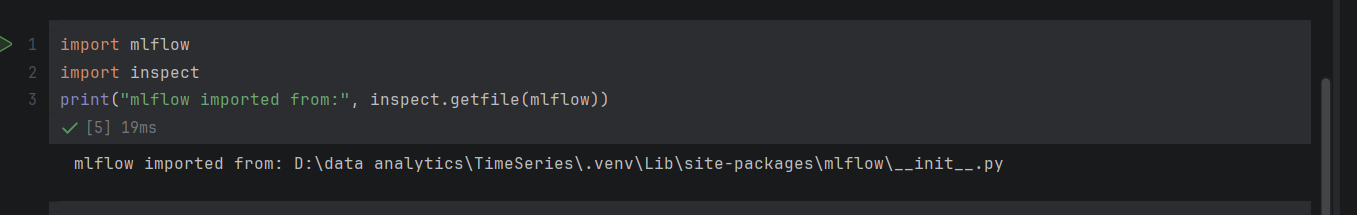

In [5]:
## baseline RF + baseline XGB
# Baseline Random Forest (use your Week 2 defaults if different)
rf_base = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)
rf_base.fit(X_train, y_train)
pred_rf = rf_base.predict(X_test)
mae_rf, rmse_rf, smape_rf = eval_metrics(y_test, pred_rf)
print("BASE RF ->", mae_rf, rmse_rf, smape_rf)

# Baseline XGBoost (use your Week 2 defaults)
xgb_base = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    objective="reg:squarederror"
)
xgb_base.fit(X_train, y_train)
pred_xgb = xgb_base.predict(X_test)
mae_xgb, rmse_xgb, smape_xgb = eval_metrics(y_test, pred_xgb)
print("BASE XGB ->", mae_xgb, rmse_xgb, smape_xgb)

BASE RF -> 106.33151851851851 152.84440894033705 23.681669067796633
BASE XGB -> 111.52606913248698 157.44557306574214 24.784602944670638


### Tune Random Forest with Hyperopt + MLflow

In [6]:
## MLflow experiment name
mlflow.set_experiment("hyperopt_rf_xgb_timeseries")

D:\data analytics\TimeSeries\.venv\Lib\site-packages\mlflow\tracking\_tracking_service\utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)
2026/03/05 17:29:03 INFO mlflow.tracking.fluent: Experiment with name 'hyperopt_rf_xgb_timeseries' does not exist. Creating a new experiment.


<Experiment: artifact_location='file:///D:/data%20analytics/TimeSeries/week_03/mlruns/259042484133543879', creation_time=1772728143045, experiment_id='259042484133543879', last_update_time=1772728143045, lifecycle_stage='active', name='hyperopt_rf_xgb_timeseries', tags={}, workspace='default'>

In [7]:
## RF search space
space_rf = {
    "n_estimators": hp.quniform("rf_n_estimators", 200, 1200, 50),
    "max_depth": hp.choice("rf_max_depth", [None, 4, 6, 8, 10, 14, 18, 24]),
    "min_samples_split": hp.quniform("rf_min_samples_split", 2, 20, 1),
    "min_samples_leaf": hp.quniform("rf_min_samples_leaf", 1, 10, 1),
    "max_features": hp.choice("rf_max_features", ["sqrt", "log2", 0.4, 0.6, 0.8, 1.0]),
    "bootstrap": hp.choice("rf_bootstrap", [True, False]),
}

In [8]:
## RF objective (logs each run)
def objective_rf(params):
    # Cast integer params
    p = params.copy()
    p["n_estimators"] = int(p["n_estimators"])
    p["min_samples_split"] = int(p["min_samples_split"])
    p["min_samples_leaf"] = int(p["min_samples_leaf"])

    with mlflow.start_run(run_name="RF", nested=True):
        model = RandomForestRegressor(
            random_state=42,
            n_jobs=-1,
            **p
        )
        model.fit(X_train, y_train)
        pred = model.predict(X_test)

        mae, rmse, s = eval_metrics(y_test, pred)

        mlflow.log_param("model_family", "RandomForest")
        for k, v in p.items():
            mlflow.log_param(k, v)
        mlflow.log_metric("MAE", mae)
        mlflow.log_metric("RMSE", rmse)
        mlflow.log_metric("sMAPE", s)

        return {"loss": mae, "status": STATUS_OK}

In [9]:
## Run RF tuning
trials_rf = Trials()
best_rf = fmin(
    fn=objective_rf,
    space=space_rf,
    algo=tpe.suggest,
    max_evals=50,
    trials=trials_rf,
    rstate=np.random.default_rng(42)
)
best_rf

100%|██████████| 50/50 [00:56<00:00,  1.12s/trial, best loss: 99.05830103742626]


{'rf_bootstrap': np.int64(0),
 'rf_max_depth': np.int64(1),
 'rf_max_features': np.int64(3),
 'rf_min_samples_leaf': np.float64(1.0),
 'rf_min_samples_split': np.float64(12.0),
 'rf_n_estimators': np.float64(1150.0)}

### Train best RF + save artifact + record final metrics

In [10]:
# Decode choices for max_depth/max_features/bootstrap from the "choice" indices
max_depth_choices = [None, 4, 6, 8, 10, 14, 18, 24]
max_features_choices = ["sqrt", "log2", 0.4, 0.6, 0.8, 1.0]
bootstrap_choices = [True, False]

best_rf_params = {
    "n_estimators": int(best_rf["rf_n_estimators"]),
    "max_depth": max_depth_choices[int(best_rf["rf_max_depth"])],
    "min_samples_split": int(best_rf["rf_min_samples_split"]),
    "min_samples_leaf": int(best_rf["rf_min_samples_leaf"]),
    "max_features": max_features_choices[int(best_rf["rf_max_features"])],
    "bootstrap": bootstrap_choices[int(best_rf["rf_bootstrap"])],
}

rf_best = RandomForestRegressor(random_state=42, n_jobs=-1, **best_rf_params)
rf_best.fit(X_train, y_train)
pred = rf_best.predict(X_test)
rf_best_mae, rf_best_rmse, rf_best_smape = eval_metrics(y_test, pred)

print("BEST RF ->", rf_best_mae, rf_best_rmse, rf_best_smape)
print("BEST RF params:", best_rf_params)

joblib.dump({"model": rf_best, "features": features}, MODELS_DIR / "rf_model.pkl")
print("Saved:", MODELS_DIR / "rf_model.pkl")

BEST RF -> 99.05830103742628 148.6561857442093 22.14825027812866
BEST RF params: {'n_estimators': 1150, 'max_depth': 4, 'min_samples_split': 12, 'min_samples_leaf': 1, 'max_features': 0.6, 'bootstrap': True}
Saved: D:\data analytics\TimeSeries\models\rf_model.pkl


### Tune XGBoost with Hyperopt + MLflow

In [11]:
space_xgb = {
    "n_estimators": hp.quniform("xgb_n_estimators", 200, 1500, 50),
    "max_depth": hp.quniform("xgb_max_depth", 2, 10, 1),
    "learning_rate": hp.loguniform("xgb_learning_rate", np.log(0.01), np.log(0.2)),
    "subsample": hp.uniform("xgb_subsample", 0.6, 1.0),
    "colsample_bytree": hp.uniform("xgb_colsample_bytree", 0.6, 1.0),
    "min_child_weight": hp.loguniform("xgb_min_child_weight", np.log(0.5), np.log(20.0)),
    "reg_alpha": hp.loguniform("xgb_reg_alpha", np.log(1e-4), np.log(10.0)),
    "reg_lambda": hp.loguniform("xgb_reg_lambda", np.log(1e-3), np.log(50.0)),
}

### XGB objective (logs each run)

In [12]:
def objective_xgb(params):
    p = params.copy()
    p["n_estimators"] = int(p["n_estimators"])
    p["max_depth"] = int(p["max_depth"])

    with mlflow.start_run(run_name="XGB", nested=True):
        model = XGBRegressor(
            random_state=42,
            n_jobs=-1,
            objective="reg:squarederror",
            **p
        )
        model.fit(X_train, y_train)
        pred = model.predict(X_test)

        mae, rmse, s = eval_metrics(y_test, pred)

        mlflow.log_param("model_family", "XGBoost")
        for k, v in p.items():
            mlflow.log_param(k, float(v))
        mlflow.log_metric("MAE", mae)
        mlflow.log_metric("RMSE", rmse)
        mlflow.log_metric("sMAPE", s)

        return {"loss": mae, "status": STATUS_OK}

### Run XGB Tuning

In [13]:
trials_xgb = Trials()
best_xgb = fmin(
    fn=objective_xgb,
    space=space_xgb,
    algo=tpe.suggest,
    max_evals=50,
    trials=trials_xgb,
    rstate=np.random.default_rng(42)
)
best_xgb

100%|██████████| 50/50 [01:04<00:00,  1.30s/trial, best loss: 102.43470458984375]


{'xgb_colsample_bytree': np.float64(0.8551298052601639),
 'xgb_learning_rate': np.float64(0.013732396473704367),
 'xgb_max_depth': np.float64(4.0),
 'xgb_min_child_weight': np.float64(5.944665022622547),
 'xgb_n_estimators': np.float64(950.0),
 'xgb_reg_alpha': np.float64(0.3231552496117284),
 'xgb_reg_lambda': np.float64(49.25459327647419),
 'xgb_subsample': np.float64(0.8294463677945988)}

### Train best XGB + save artifact + record final metrics

In [14]:
best_xgb_params = {
    "n_estimators": int(best_xgb["xgb_n_estimators"]),
    "max_depth": int(best_xgb["xgb_max_depth"]),
    "learning_rate": float(best_xgb["xgb_learning_rate"]),
    "subsample": float(best_xgb["xgb_subsample"]),
    "colsample_bytree": float(best_xgb["xgb_colsample_bytree"]),
    "min_child_weight": float(best_xgb["xgb_min_child_weight"]),
    "reg_alpha": float(best_xgb["xgb_reg_alpha"]),
    "reg_lambda": float(best_xgb["xgb_reg_lambda"]),
}

xgb_best = XGBRegressor(
    random_state=42,
    n_jobs=-1,
    objective="reg:squarederror",
    **best_xgb_params
)
xgb_best.fit(X_train, y_train)
pred = xgb_best.predict(X_test)
xgb_best_mae, xgb_best_rmse, xgb_best_smape = eval_metrics(y_test, pred)

print("BEST XGB ->", xgb_best_mae, xgb_best_rmse, xgb_best_smape)
print("BEST XGB params:", best_xgb_params)

joblib.dump({"model": xgb_best, "features": features}, MODELS_DIR / "xgboost_model.pkl")
print("Saved:", MODELS_DIR / "xgboost_model.pkl")

BEST XGB -> 102.43470458984375 151.2703514446311 22.88803930017962
BEST XGB params: {'n_estimators': 950, 'max_depth': 4, 'learning_rate': 0.013732396473704367, 'subsample': 0.8294463677945988, 'colsample_bytree': 0.8551298052601639, 'min_child_weight': 5.944665022622547, 'reg_alpha': 0.3231552496117284, 'reg_lambda': 49.25459327647419}
Saved: D:\data analytics\TimeSeries\models\xgboost_model.pkl


### Pick the best tuned ML model + write metrics_ml.csv

In [15]:
ml_rows = [
    {"Model": "Random Forest (tuned)", "MAE": rf_best_mae, "RMSE": rf_best_rmse, "sMAPE": rf_best_smape},
    {"Model": "XGBoost (tuned)",       "MAE": xgb_best_mae, "RMSE": xgb_best_rmse, "sMAPE": xgb_best_smape},
]

ml_df_tuned = pd.DataFrame(ml_rows).sort_values("MAE").reset_index(drop=True)
print("Best tuned ML model:", ml_df_tuned.iloc[0]["Model"])
ml_df_tuned

Best tuned ML model: Random Forest (tuned)


,Model,MAE,RMSE,sMAPE
0,Random Forest (tuned),99.058301,148.656186,22.148250
1,XGBoost (tuned),102.434705,151.270351,22.888039


In [16]:
ml_df_tuned.to_csv(MODELS_DIR / "metrics_ml_tuned.csv", index=False)
print("Saved:", MODELS_DIR / "metrics_ml_tuned.csv")

Saved: D:\data analytics\TimeSeries\models\metrics_ml_tuned.csv
